# Técnicas de remuestro

Las técnicas de remuestreo son métodos estadísticos donde se obtienen muestras de un conjunto de datos, en este caso un muestra obtenida, para poder estimar la precisión de un estadístico, prueba de hipotésis, o evaluar modelos de aprendizaje automático sin asumir cuestiones paramétricas.

Tenemos 12 valores dados por tiempos de entrega, siendo $[35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]$, siendo su media:

$$
\overline{x}=\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}=\frac{480}{12}=40
$$

In [ ]:
#Librerías a usar
import numpy as np
import matplotlib.pyplot as plt
import random

# Datos originales
datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
n = len(datos)
media_original = np.mean(datos)
print(f"Datos: {datos}")
print(f"Media original: {media_original:.4f}\n")

Datos: [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
Media original: 40.0000



## Bootstrap
El bootstrap es una técnica de remuestreo con reemplazo que permite estimar la distribución de un estadístico (media, varianza, etc.) a partir de una muestra original. Consiste en:

* Generar B muestras de tamaño n (igual al tamaño original) extrayendo aleatoriamente con reemplazo de la muestra original.

* Calcular el estadístico de interés en cada muestra bootstrap.

* Usar la distribución empírica de estos B estadísticos para estimar errores estándar, intervalos de confianza, sesgo, etc.

El método es no paramétrico y funciona bien cuando la muestra es representativa de la población.

## Proceso 
Repetir 1000 veces:

* Seleccionar 12 observaciones con reemplazo de datos usando muestro aleatorio simple con reemplazo.

* Calcular la media de esa muestra bootstrap y guardarla.

Con las 1000 medias bootstrap:

* Calcular la media de las medias (estimación de la media poblacional).

* Calcular la desviación estándar de las medias (error estándar bootstrap).

* Obtener los percentiles 2.5% y 97.5% para un intervalo de confianza al 95%.

## Aplicación de Bootstrap con los datos dados

In [13]:
# Parámetros del bootstrap
B = 1000
medias_bootstrap = []

for i in range(B):
    # Muestra con reemplazo del mismo tamaño que el original
    muestra_boot = np.random.choice(datos, size=n, replace=True)
    medias_bootstrap.append(np.mean(muestra_boot))

# Convertir a array para cálculos
medias_bootstrap = np.array(medias_bootstrap)

# Estadísticas bootstrap
media_bootstrap = np.mean(medias_bootstrap)
std_bootstrap = np.std(medias_bootstrap, ddof=1)  # desviación estándar de las medias
percentil_2_5 = np.percentile(medias_bootstrap, 2.5)
percentil_97_5 = np.percentile(medias_bootstrap, 97.5)

print("=== RESULTADOS BOOTSTRAP ===")
print(f"Número de remuestras: {B}")
print(f"Media de las medias bootstrap: {media_bootstrap:.4f}")
print(f"Error estándar bootstrap: {std_bootstrap:.4f}")
print(f"Intervalo de confianza al 95%: [{percentil_2_5:.4f}, {percentil_97_5:.4f}]")

=== RESULTADOS BOOTSTRAP ===
Número de remuestras: 1000
Media de las medias bootstrap: 39.9798
Error estándar bootstrap: 0.8887
Intervalo de confianza al 95%: [38.0833, 41.6687]


## Histograma con los intervalos de confianza

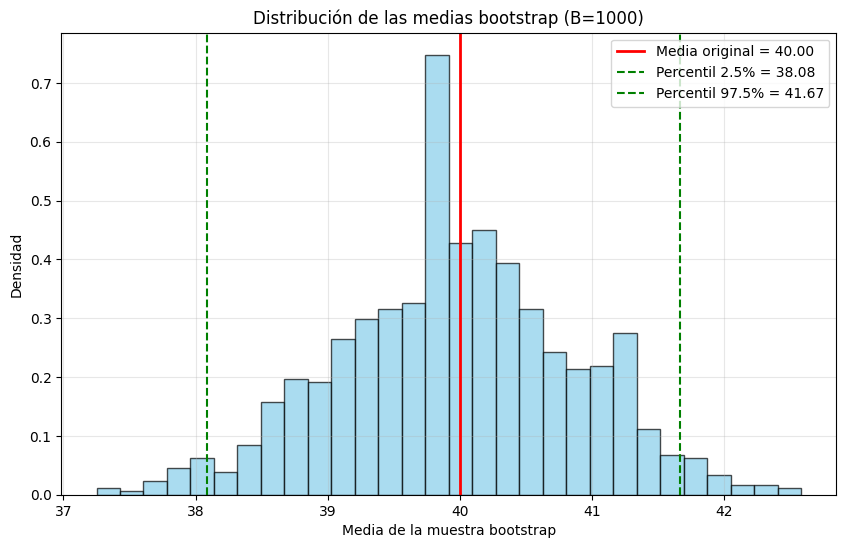

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(medias_bootstrap, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(media_original, color='red', linestyle='-', linewidth=2, label=f'Media original = {media_original:.2f}')
plt.axvline(percentil_2_5, color='green', linestyle='--', linewidth=1.5, label=f'Percentil 2.5% = {percentil_2_5:.2f}')
plt.axvline(percentil_97_5, color='green', linestyle='--', linewidth=1.5, label=f'Percentil 97.5% = {percentil_97_5:.2f}')
plt.xlabel('Media de la muestra bootstrap')
plt.ylabel('Densidad')
plt.title('Distribución de las medias bootstrap (B=1000)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Gráfica de convergencia de la media

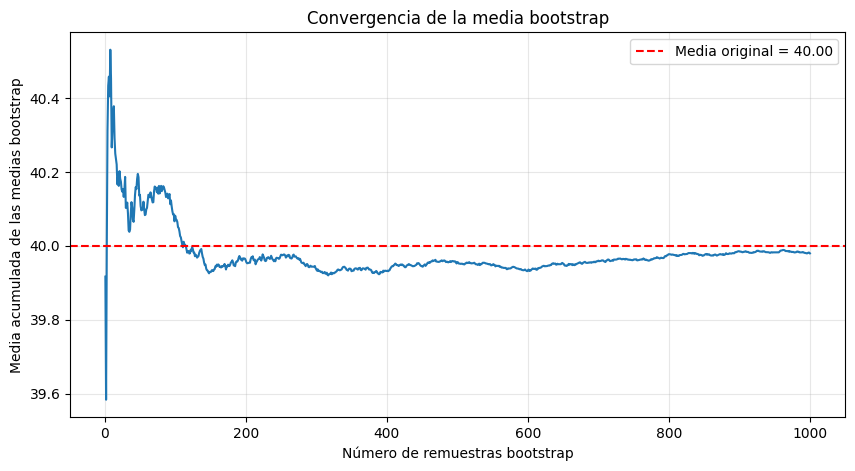

In [23]:
# Media acumulada a medida que aumentan las remuestras
media_acumulada = np.cumsum(medias_bootstrap) / np.arange(1, B+1)

plt.figure(figsize=(10, 5))
plt.plot(range(1, B+1), media_acumulada, linewidth=1.5)
plt.axhline(media_original, color='red', linestyle='--', label=f'Media original = {media_original:.2f}')
plt.xlabel('Número de remuestras bootstrap')
plt.ylabel('Media acumulada de las medias bootstrap')
plt.title('Convergencia de la media bootstrap')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Jackknife

El jackknife es otro método de remuestreo pero sin reemplazo. Para una muestra de tamaño n-1:

* Se crean n submuestras, cada una eliminando una observación diferente (dejando fuera una a la vez).

* Se calcula el estadístico en cada submuestra.
* A partir de estos n valores se estima el sesgo y el error estándar del estadístico.

El jackknife es más simple computacionalmente y es útil para estimar la varianza de un estimador, pero es menos preciso que bootstrap en distribuciones asimétricas.

## Proceso 
Para cada observación $i$ (de 1 a 12):

* Crear una muestra eliminando el elemento $i$.

* Calcular la media de esa muestra (media jackknife).

Con las $n$ medias jackknife:

* Calcular su media (media de las medias jackknife), siendo:
$$
\theta=\frac{1}{n}\sum_{i=0}^{n} \bar{\theta}_{i}
$$

* Estimar la varianza y el error estándar jackknife mediante la fórmula:

$$
Var(\bar{\theta}_{\text{jack}})=\frac{n-1}{n}\sum_{i=1}^{n}(\theta-\bar{\theta}_{i})^{2}
$$
donde $\bar{\theta}_{i}$ es la media eliminando la observación $i$ y $\theta$ es el promedio de esas medias.
* El error estándar es la raíz cuadrada de esa varianza.
* El sesgo estimado: $(n-1)(\bar{\theta}-\theta)$

## Aplicación de Jackknife a los datos dados

In [20]:
# Jackknife: eliminar una observación cada vez
medias_jack = []

for i in range(n):
    muestra_jack = np.delete(datos, i)  # elimina el elemento en posición i
    medias_jack.append(np.mean(muestra_jack))

medias_jack = np.array(medias_jack)

# Estadísticas jackknife
media_jack = np.mean(medias_jack)          # promedio de las medias jackknife
sesgo_jack = (n - 1) * (media_jack - media_original)

# Varianza jackknife (fórmula estándar)
var_jack = (n - 1) / n * np.sum((medias_jack - media_jack)**2)
error_estandar_jack = np.sqrt(var_jack)

print("\n=== RESULTADOS JACKKNIFE ===")
print(f"Media de las medias jackknife: {media_jack:.4f}")
print(f"Sesgo estimado: {sesgo_jack:.4f}")
print(f"Varianza jackknife: {var_jack:.6f}")
print(f"Error estándar jackknife: {error_estandar_jack:.4f}")

# Intervalo de confianza aproximado (usando distribución t con n-1 grados de libertad)
from scipy import stats
t_value = stats.t.ppf(0.975, df=n-1)
ic_jack_inf = media_original - t_value * error_estandar_jack
ic_jack_sup = media_original + t_value * error_estandar_jack
print(f"Intervalo de confianza 95% (aproximado t): [{ic_jack_inf:.4f}, {ic_jack_sup:.4f}]")


=== RESULTADOS JACKKNIFE ===
Media de las medias jackknife: 40.0000
Sesgo estimado: 0.0000
Varianza jackknife: 0.833333
Error estándar jackknife: 0.9129
Intervalo de confianza 95% (aproximado t): [37.9908, 42.0092]


## Histograma de los intervalos de confianza

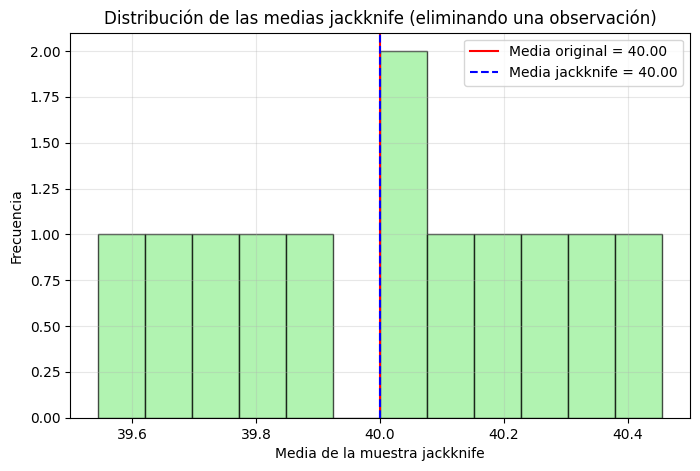

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(medias_jack, bins=12, alpha=0.7, color='lightgreen', edgecolor='black')
plt.axvline(media_original, color='red', linestyle='-', label=f'Media original = {media_original:.2f}')
plt.axvline(media_jack, color='blue', linestyle='--', label=f'Media jackknife = {media_jack:.2f}')
plt.xlabel('Media de la muestra jackknife')
plt.ylabel('Frecuencia')
plt.title('Distribución de las medias jackknife (eliminando una observación)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Comparación entre métodos

In [22]:
print("\n=== COMPARACIÓN DE INTERVALOS 95% ===")
print(f"Bootstrap (percentiles): [{percentil_2_5:.4f}, {percentil_97_5:.4f}]")
print(f"Jackknife (t-student):   [{ic_jack_inf:.4f}, {ic_jack_sup:.4f}]")


=== COMPARACIÓN DE INTERVALOS 95% ===
Bootstrap (percentiles): [38.0833, 41.6687]
Jackknife (t-student):   [37.9908, 42.0092]
